<a href="https://colab.research.google.com/github/AhmedMB02/Biblio/blob/master/TP4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Importation des bibliothèques**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

# **Chargement du dataset**

In [11]:
!wget "https://raw.githubusercontent.com/profsarang/ThinkingDataScience/main/data/voice.csv"

--2026-06-26 18:05:00--  https://raw.githubusercontent.com/profsarang/ThinkingDataScience/main/data/voice.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1065381 (1.0M) [text/plain]
Saving to: ‘voice.csv’

voice.csv           100%[===================>]   1.02M  --.-KB/s    in 0.05s   

2026-06-26 18:05:00 (21.6 MB/s) - ‘voice.csv’ saved [1065381/1065381]



In [12]:
df = pd.read_csv("voice.csv")

print(df.head())
print(df.info())
print(df["label"].value_counts())

   meanfreq        sd    median       Q25       Q75       IQR       skew  \
0  0.059781  0.064241  0.032027  0.015071  0.090193  0.075122  12.863462   
1  0.066009  0.067310  0.040229  0.019414  0.092666  0.073252  22.423285   
2  0.077316  0.083829  0.036718  0.008701  0.131908  0.123207  30.757155   
3  0.151228  0.072111  0.158011  0.096582  0.207955  0.111374   1.232831   
4  0.135120  0.079146  0.124656  0.078720  0.206045  0.127325   1.101174   

          kurt    sp.ent       sfm  ...  centroid   meanfun    minfun  \
0   274.402906  0.893369  0.491918  ...  0.059781  0.084279  0.015702   
1   634.613855  0.892193  0.513724  ...  0.066009  0.107937  0.015826   
2  1024.927705  0.846389  0.478905  ...  0.077316  0.098706  0.015656   
3     4.177296  0.963322  0.727232  ...  0.151228  0.088965  0.017798   
4     4.333713  0.971955  0.783568  ...  0.135120  0.106398  0.016931   

     maxfun   meandom    mindom    maxdom   dfrange   modindx  label  
0  0.275862  0.007812  0.007812  

In [13]:
# 2. Vérifier les valeurs manquantes
print(df.isnull().sum())

meanfreq    0
sd          0
median      0
Q25         0
Q75         0
IQR         0
skew        0
kurt        0
sp.ent      0
sfm         0
mode        0
centroid    0
meanfun     0
minfun      0
maxfun      0
meandom     0
mindom      0
maxdom      0
dfrange     0
modindx     0
label       0
dtype: int64


# **Encodage du Label**

In [14]:
# female = 0, male = 1
encoder = LabelEncoder()
df["label"] = encoder.fit_transform(df["label"])

# **Séparation des x et y**

In [15]:
X = df.drop("label", axis=1)
y = df["label"]


# **Train / Test**

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# **Heatmap de corrélation**

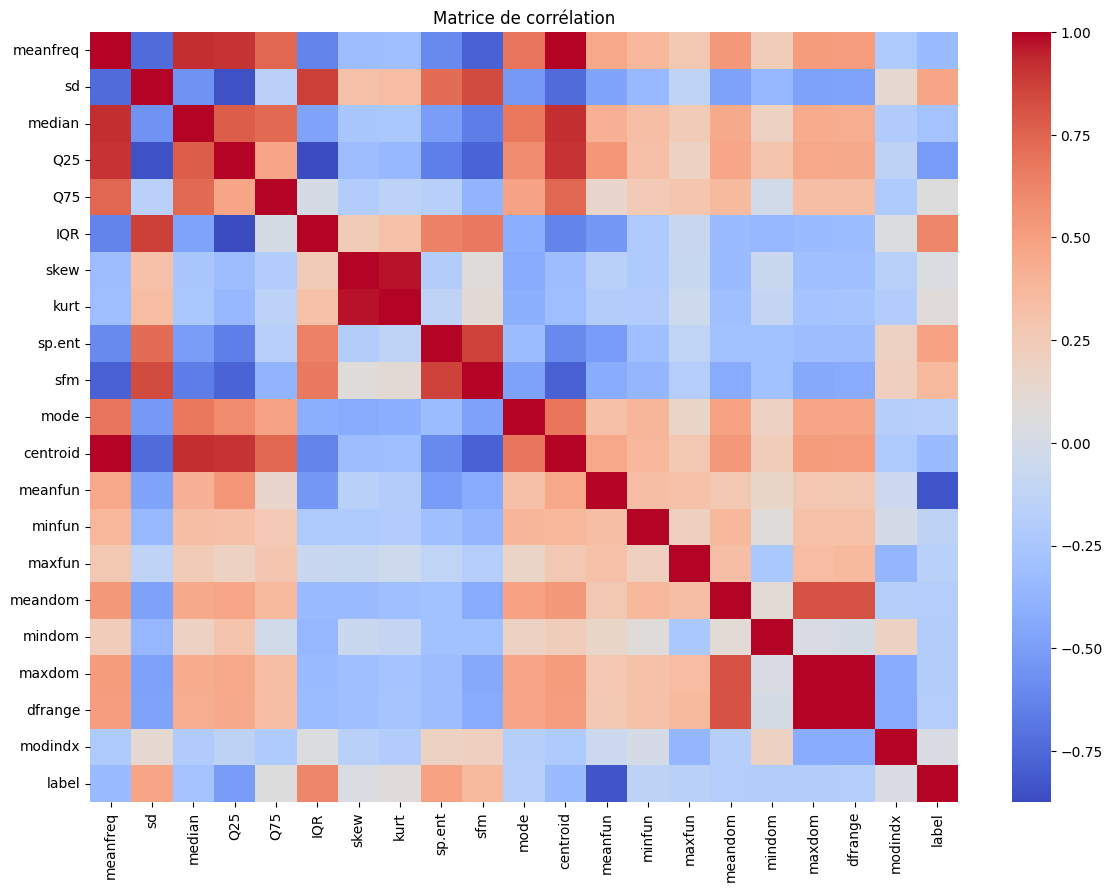

In [17]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Matrice de corrélation")
plt.show()

# **Normalisation**

In [18]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# **PCA avec 95% de variance**

In [19]:
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Nombre de composantes PCA :", pca.n_components_)
print("Variance expliquée :", sum(pca.explained_variance_ratio_))


Nombre de composantes PCA : 10
Variance expliquée : 0.9599886702685924


# **Visualisation PCA 2D**

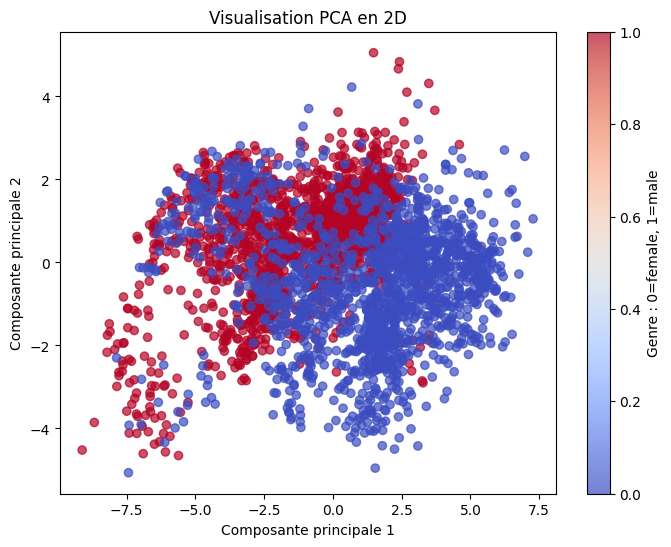

In [20]:
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(scaler.fit_transform(X))

plt.figure(figsize=(8, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap="coolwarm", alpha=0.7)
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.title("Visualisation PCA en 2D")
plt.colorbar(label="Genre : 0=female, 1=male")
plt.show()

# **SVM linéaire**

In [22]:
svm_linear = SVC(kernel="linear")
svm_linear.fit(X_train_pca, y_train)
y_pred_linear = svm_linear.predict(X_test_pca)

print("Résultats SVM Linéaire")
print(classification_report(y_test, y_pred_linear))

Résultats SVM Linéaire
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       317
           1       0.97      0.98      0.97       317

    accuracy                           0.97       634
   macro avg       0.97      0.97      0.97       634
weighted avg       0.97      0.97      0.97       634



# **SVM RBF**

In [23]:
svm_rbf = SVC(kernel="rbf")
svm_rbf.fit(X_train_pca, y_train)

y_pred_rbf = svm_rbf.predict(X_test_pca)

print("Résultats SVM RBF")
print(classification_report(y_test, y_pred_rbf))

Résultats SVM RBF
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       317
           1       0.97      0.99      0.98       317

    accuracy                           0.98       634
   macro avg       0.98      0.98      0.98       634
weighted avg       0.98      0.98      0.98       634



# **Optimisation avec GridSearchCV**

In [24]:
param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", "auto", 0.01, 0.1, 1],
    "kernel": ["linear", "rbf", "poly"]
}

grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train_pca, y_train)

print("Meilleurs paramètres :", grid.best_params_)
print("Meilleur score CV :", grid.best_score_)

Meilleurs paramètres : {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Meilleur score CV : 0.9759283080353315


# **Évaluation du meilleur modèle**


In [25]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test_pca)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1-score :", f1)

print("\nRapport de classification :")
print(classification_report(y_test, y_pred))

Accuracy : 0.9779179810725552
Precision : 0.9690402476780186
Recall : 0.9873817034700315
F1-score : 0.978125

Rapport de classification :
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       317
           1       0.97      0.99      0.98       317

    accuracy                           0.98       634
   macro avg       0.98      0.98      0.98       634
weighted avg       0.98      0.98      0.98       634



# **Matrice de confusion**

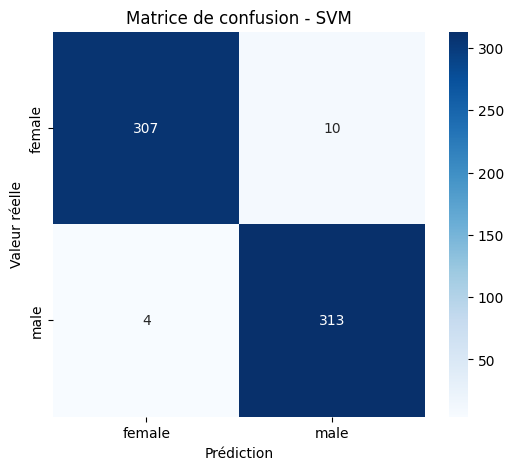

In [26]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["female", "male"],
    yticklabels=["female", "male"]
)

plt.xlabel("Prédiction")
plt.ylabel("Valeur réelle")
plt.title("Matrice de confusion - SVM")
plt.show()